In [ ]:
!pip install snowflake-connector-python pandas scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 3.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pyopenssl to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 118.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.6 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
  Attempting uninstall: pyOpenSSL
    Found

In [ ]:
import snowflake.connector
import pandas as pd

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
query = "select * from waterdb"

In [ ]:
con = snowflake.connector.connect(
    user = "Alaguraja",
    password = "Alagurajakannan@787",
    account = "DXMKEOQ-ON75318",
    database = "water",
    schema = "PUBLIC",
    warehouse = "COMPUTE_WH"
)

In [ ]:
df = pd.read_sql(query, con)

/tmp/ipykernel_1282/1914986641.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con)


In [ ]:
df

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


##**EDA process**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PH               2785 non-null   float64
 1   HARDNESS         3276 non-null   float64
 2   SOLIDS           3276 non-null   float64
 3   CHLORAMINES      3276 non-null   float64
 4   SULFATE          2495 non-null   float64
 5   CONDUCTIVITY     3276 non-null   float64
 6   ORGANIC_CARBON   3276 non-null   float64
 7   TRIHALOMETHANES  3114 non-null   float64
 8   TURBIDITY        3276 non-null   float64
 9   POTABILITY       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [ ]:
df.describe()

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [ ]:
df.shape

(3276, 10)

##**Data preprocessing**

In [ ]:
df.isnull().sum()

,0
PH,491
HARDNESS,0
SOLIDS,0
CHLORAMINES,0
SULFATE,781
CONDUCTIVITY,0
ORGANIC_CARBON,0
TRIHALOMETHANES,162
TURBIDITY,0
POTABILITY,0


In [ ]:
col = ["PH","SULFATE", "TRIHALOMETHANES"]

In [ ]:
for i in col:
  df[i] = df[i].fillna(df[i]).mean()

In [ ]:
df.isnull().sum()

,0
PH,0
HARDNESS,0
SOLIDS,0
CHLORAMINES,0
SULFATE,0
CONDUCTIVITY,0
ORGANIC_CARBON,0
TRIHALOMETHANES,0
TURBIDITY,0
POTABILITY,0


In [ ]:
df.duplicated().sum()

np.int64(0)

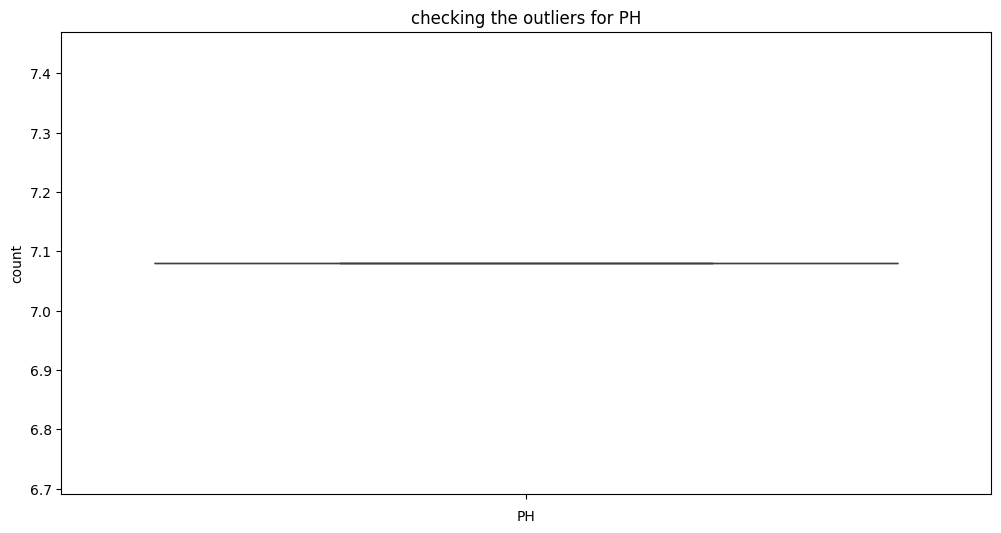

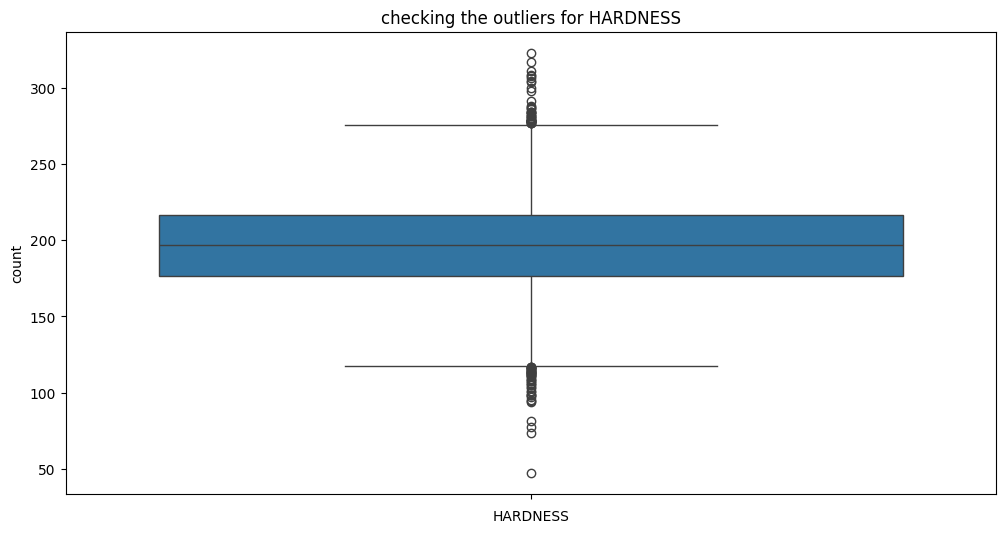

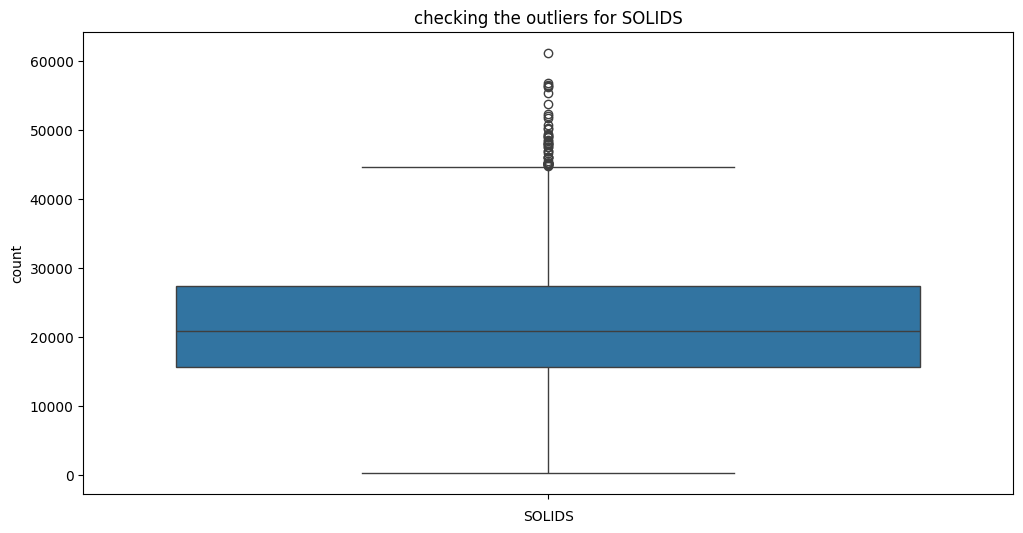

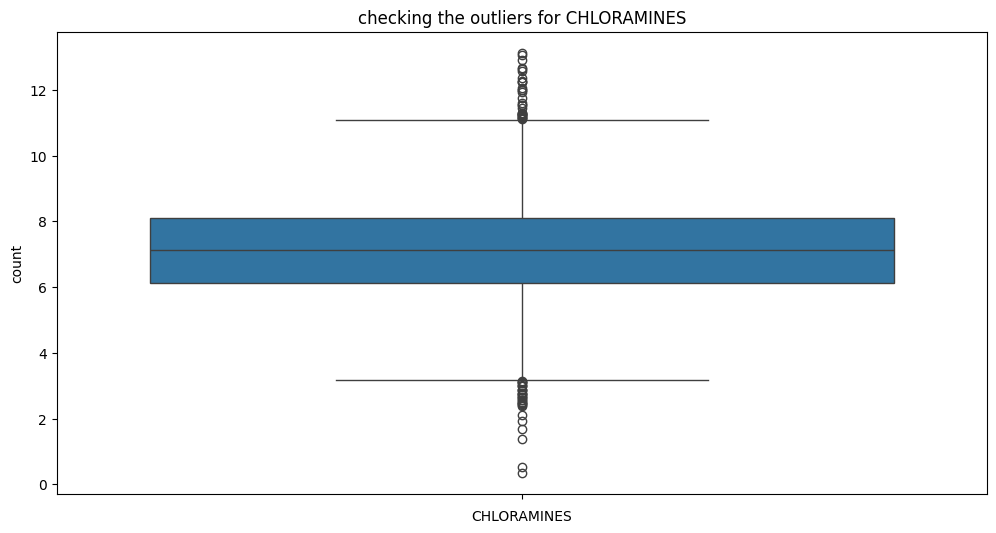

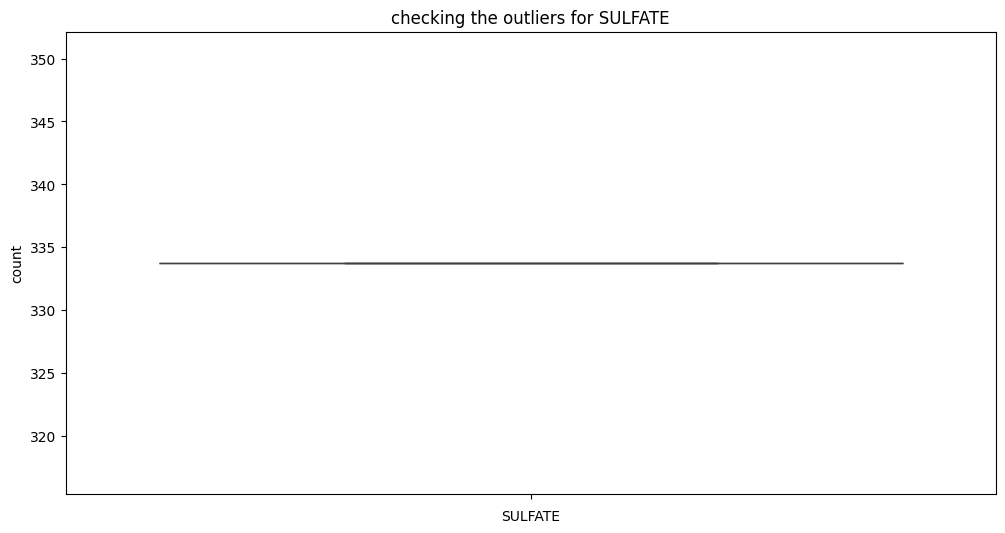

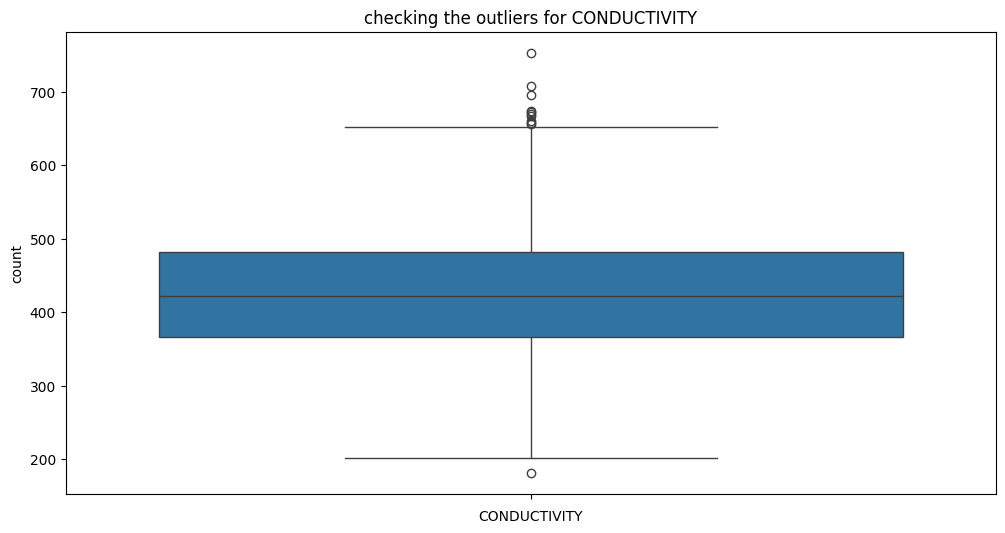

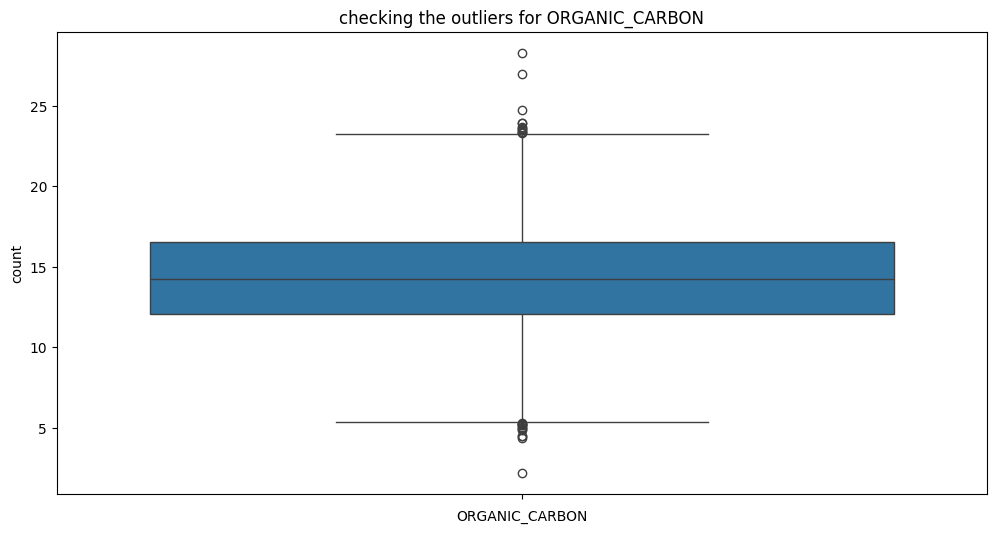

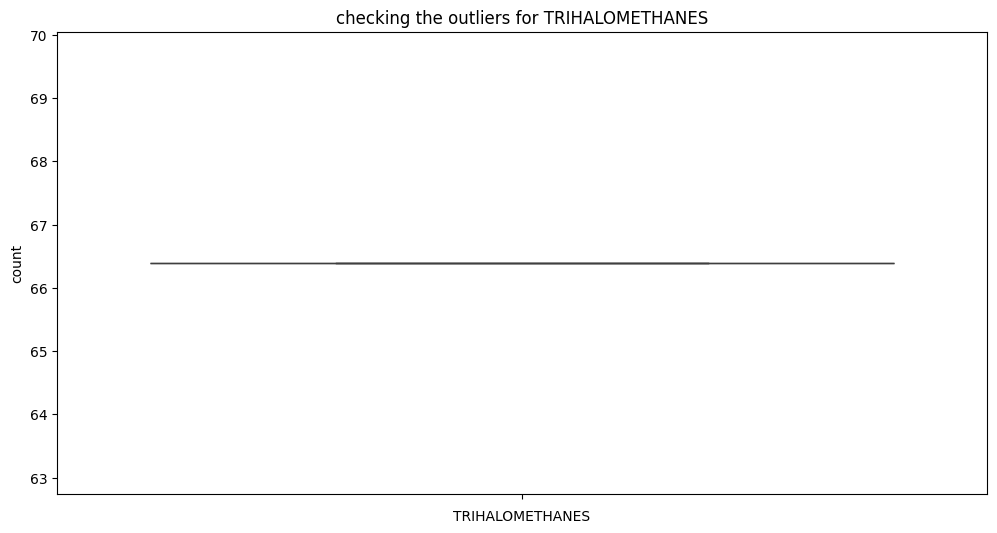

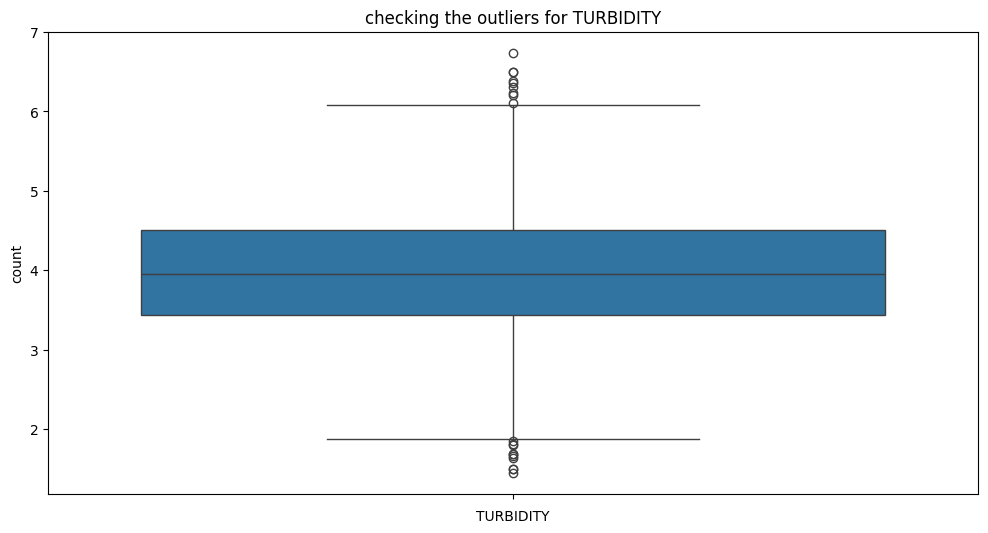

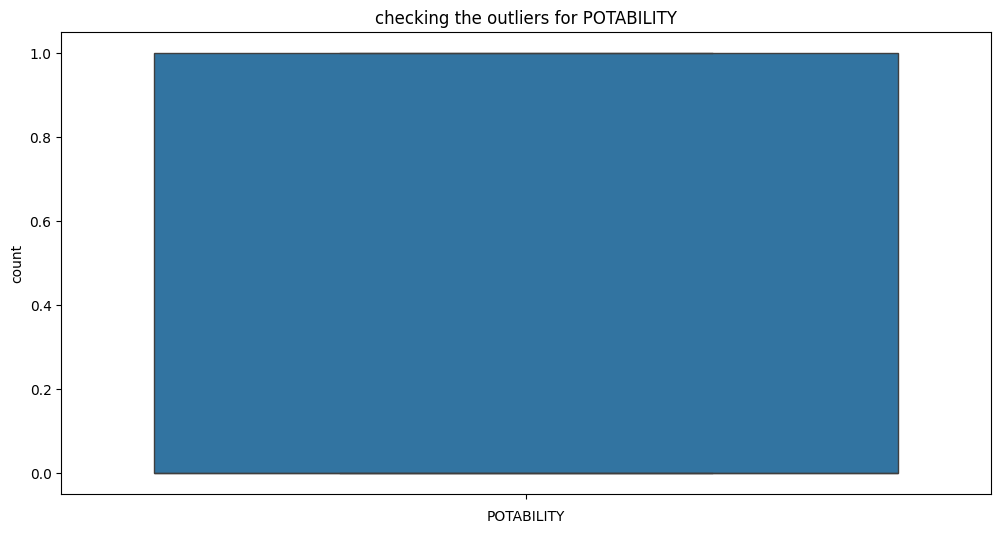

In [ ]:
for i in df.columns:
  if df[i].dtypes !="object":
    plt.figure(figsize=(12,6))
    sns.boxplot(df[i])
    plt.title(f"checking the outliers for {i}")
    plt.xlabel(i)
    plt.ylabel("count")
    plt.show()

In [ ]:
data = ["HARDNESS","SOLIDS","CHLORAMINES", "CONDUCTIVITY", "ORGANIC_CARBON", "TURBIDITY"]

In [ ]:
df.columns

Index(['PH', 'HARDNESS', 'SOLIDS', 'CHLORAMINES', 'SULFATE', 'CONDUCTIVITY',
       'ORGANIC_CARBON', 'TRIHALOMETHANES', 'TURBIDITY', 'POTABILITY'],
      dtype='object')

In [ ]:
col = ['PH', 'HARDNESS', 'SOLIDS', 'CHLORAMINES', 'SULFATE', 'CONDUCTIVITY',
       'ORGANIC_CARBON', 'TRIHALOMETHANES', 'TURBIDITY']

In [ ]:
from sklearn.preprocessing import RobustScaler
ss = RobustScaler()
for i in col:
    df[i] = ss.fit_transform(df[[i]])

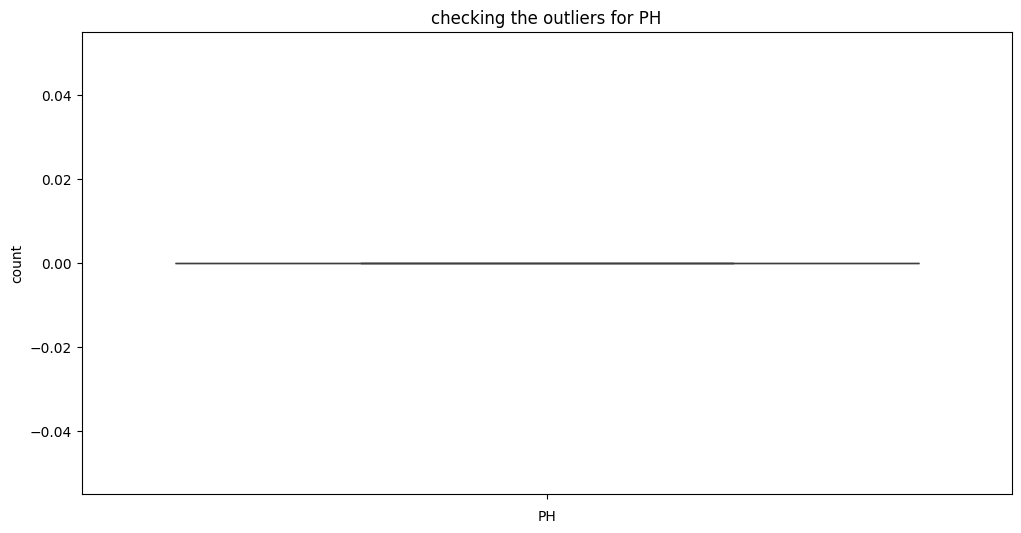

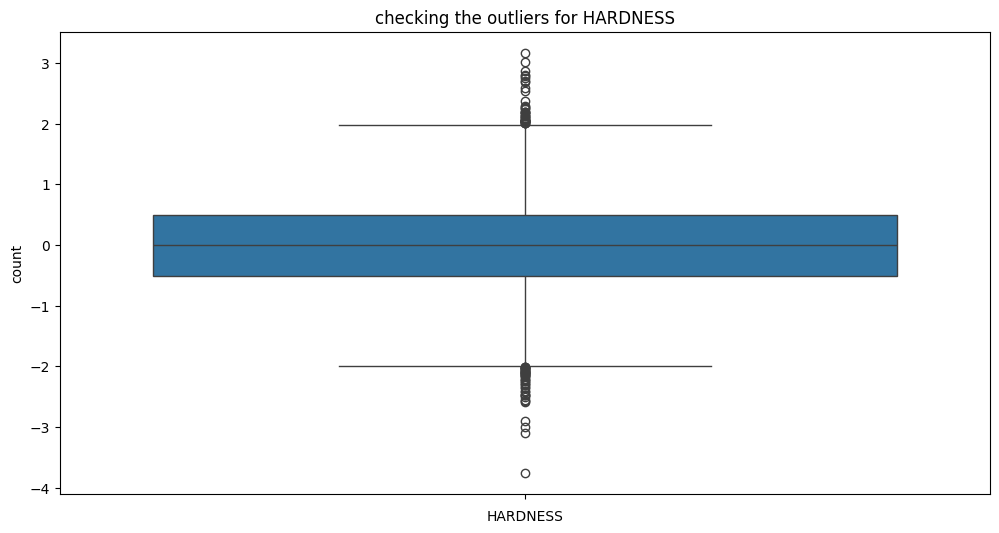

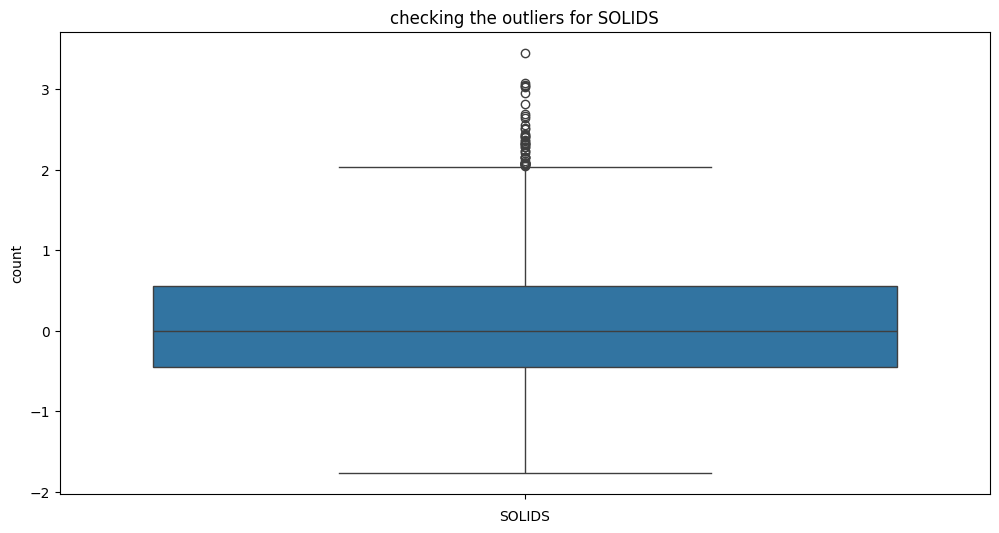

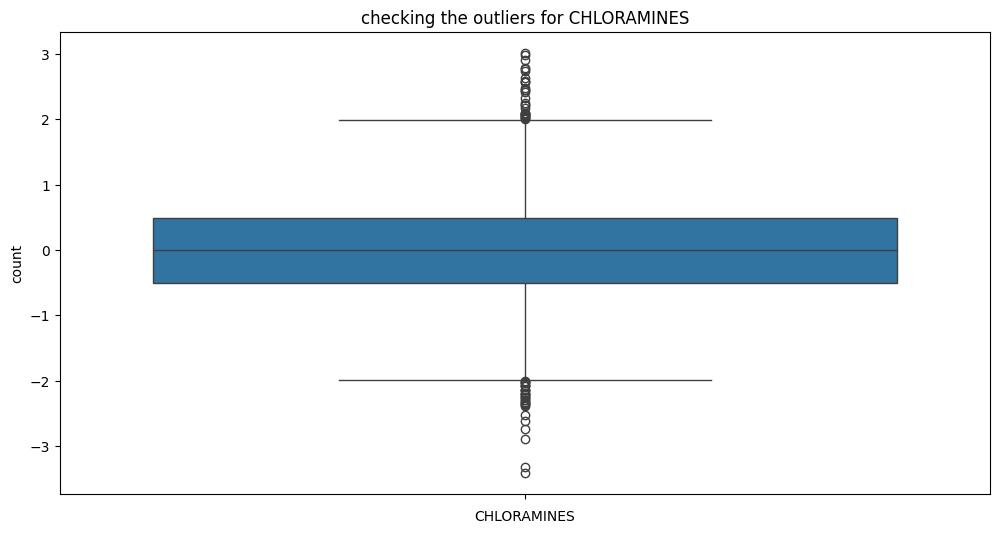

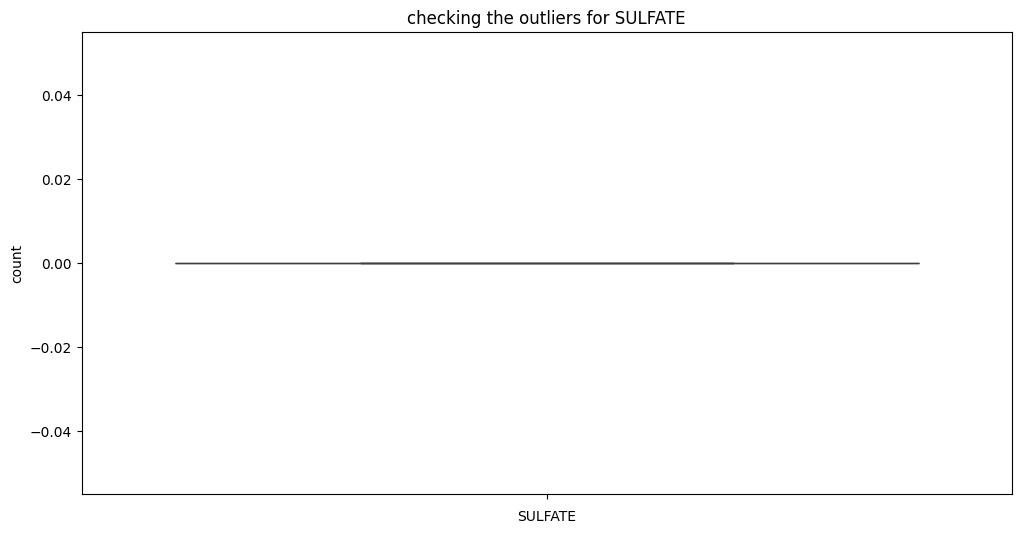

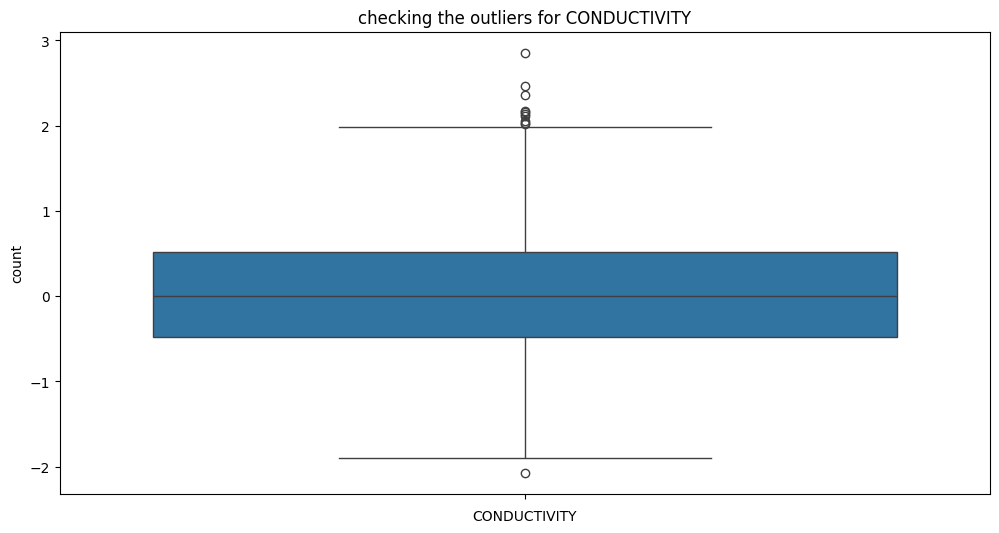

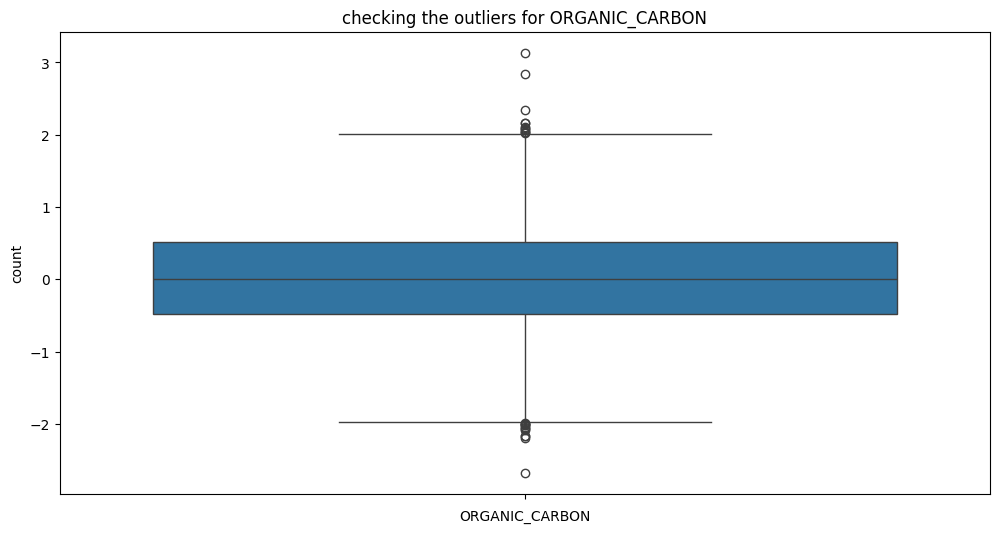

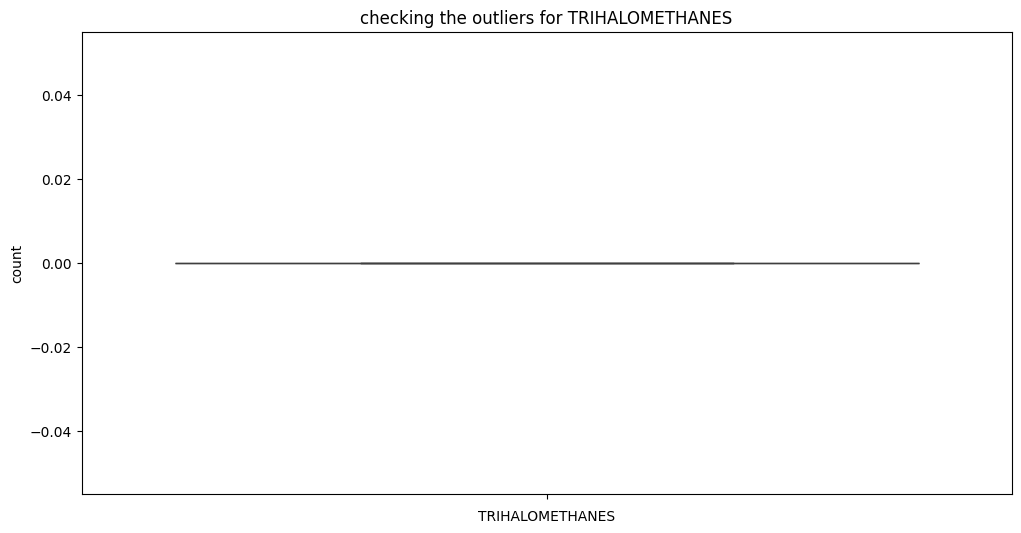

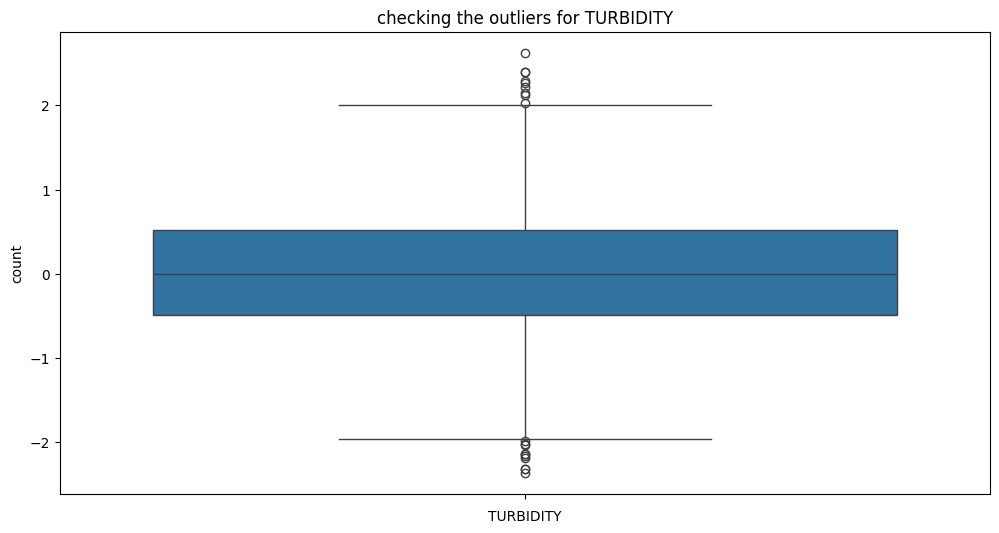

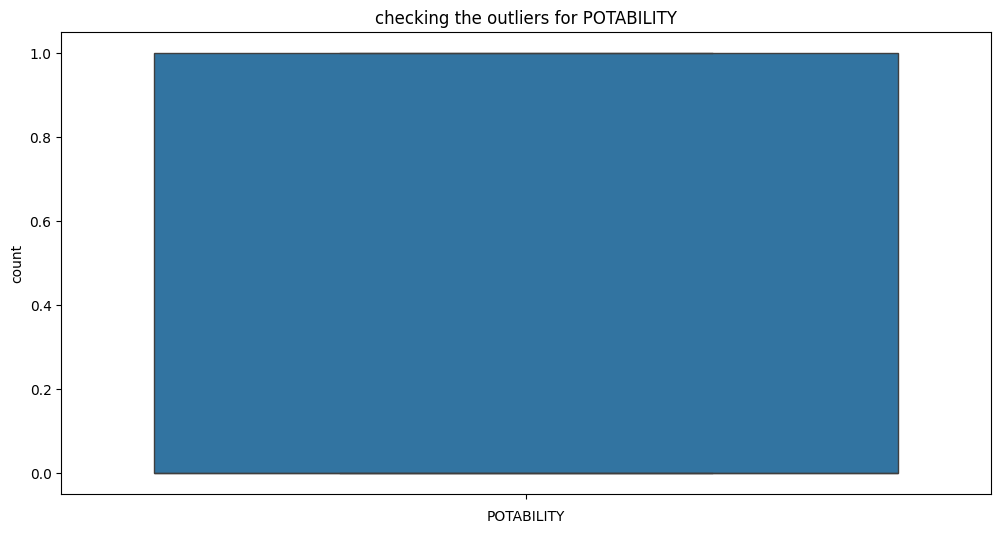

In [ ]:
for i in df.columns:
  if df[i].dtypes !="object":
    plt.figure(figsize=(12,6))
    sns.boxplot(df[i])
    plt.title(f"checking the outliers for {i}")
    plt.xlabel(i)
    plt.ylabel("count")
    plt.show()

In [ ]:
df

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
0,0.0,0.198981,-0.011702,0.085492,0.0,1.227178,-0.854560,0.0,-0.935210,0
1,0.0,-1.696382,-0.196962,-0.249088,0.0,1.473406,0.214093,0.0,0.514449,0
2,0.0,0.684850,-0.087287,1.079558,0.0,-0.028251,0.590024,0.0,-0.847715,0
3,0.0,0.437145,0.093483,0.467446,0.0,-0.505079,0.939076,0.0,0.635242,0
4,0.0,-0.398477,-0.252771,-0.293690,0.0,-0.202262,-0.592197,0.0,0.113188,0
...,...,...,...,...,...,...,...,...,...,...
3271,0.0,-0.082525,2.284673,0.018285,0.0,0.900750,-0.072113,0.0,0.453318,1
3272,0.0,-0.085753,-0.308418,0.468467,0.0,-0.253627,1.265600,0.0,-1.090680,1
3273,0.0,-0.532562,1.048146,0.110661,0.0,0.087541,-0.707786,0.0,-0.618656,1
3274,0.0,0.844770,-0.766665,-0.416079,0.0,-0.163727,-0.678872,0.0,0.710564,1


In [ ]:
x = df.iloc[:,:-1]
y = df[["POTABILITY"]]

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size =0.2, random_state = 42)

In [ ]:
x_train

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY
233,0.0,0.152260,-0.322348,-0.543757,0.0,-0.100310,0.377609,0.0,-0.980438
831,0.0,-0.078527,1.134002,1.381797,0.0,0.656388,-1.202084,0.0,0.071310
2658,0.0,0.218502,-0.223426,-0.210039,0.0,0.625544,-0.091146,0.0,0.940479
2495,0.0,-0.338519,-0.707341,1.332102,0.0,0.521809,-0.202281,0.0,-0.673772
2603,0.0,-0.353681,-0.263737,0.167278,0.0,-0.199084,0.686416,0.0,0.583571
...,...,...,...,...,...,...,...,...,...
1095,0.0,0.286475,0.075593,-0.646143,0.0,-1.356021,-0.664135,0.0,0.601477
1130,0.0,-0.803896,0.392512,0.371195,0.0,-0.201836,0.240248,0.0,0.249857
1294,0.0,-0.256337,0.858146,0.288398,0.0,-0.784168,-0.089625,0.0,-0.437899
860,0.0,0.529052,-0.406670,0.130908,0.0,-0.283163,0.475568,0.0,0.300874


In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
model = SVC()
scores = cross_val_score(model, X_train_smote, y_train_smote, cv = 5)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

In [ ]:
params = {
    'C' : [0.1,1,10,3,4,6,8,7,9,11],
    'kernel': ["rbf", "linear", "poly"],
    'gamma' : ['scale', 'auto'],
    'random_state' : [22,32,42,54,67,87]
}

In [ ]:
grid = RandomizedSearchCV(
    estimator=model,
    param_distributions =params,
    cv=5,
    random_state = 42,
    n_iter = 10,
    scoring='accuracy')

In [ ]:
grid.fit(X_train_smote, y_train_smote)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
model = SVC(kernel = 'rbf', gamma ='auto', C = 10)

In [ ]:
model.fit(x_train, y_train)

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import *
print("Performance of my model is:", accuracy_score(y_test, y_pred)*100)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion = 'log_loss')
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import *
print("Performance of my model is:", accuracy_score(y_test, y_pred)*100)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators = 400)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print(f"Performance of my model :", accuracy_score(y_test, y_pred)*100)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Performance of my model : 62.04268292682927
